# Atividade Prática 01 — Segmentação de Clientes com Aprendizado Não Supervisionado

**Disciplina:** Aprendizado de Máquina Não Supervisionado  
**MBA:** Inteligência Artificial Aplicada — UNISINOS  
**Aluno:** Matheus Teixeira Rohde

**Repositório do projeto:**  
https://github.com/Matrohde/segmentacao-clientes-aprendizado-nao-supervisionado

1. Importação e análise inicial dos dados

Nesta etapa, o dataset Online Retail foi carregado e inspecionado para entender sua estrutura, suas variáveis e identificar possíveis problemas nos dados antes da análise.

In [122]:
# Conecta o Google Colab ao Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
# Bibliotecas para manipulação e análise dos dados

import pandas as pd
import numpy as np

In [124]:
# Caminho do dataset no Google Drive

caminho = "/content/drive/MyDrive/Online Retail.xlsx"

# Carrega o arquivo Excel
df = pd.read_excel(caminho)

# Visualiza as primeiras linhas
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [125]:
# Quantidade de linhas e colunas do dataset

df.shape

(541909, 8)

In [126]:
# Quantidade de valores ausentes em cada variável

df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [127]:
# Quantidade de linhas completamente duplicadas

df.duplicated().sum()

np.int64(5268)

In [128]:
# Estatísticas descritivas das variáveis numéricas

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Principais achados: A base possui 541.909 registros e 8 variáveis. Foram encontrados 135.080 valores ausentes em CustomerID, 1.454 em Description e 5.268 registros duplicados. A análise descritiva também mostrou valores negativos em Quantity e UnitPrice, que serão investigados na etapa de limpeza.

2. Limpeza dos dados

Nesta etapa, serão investigados e tratados registros que podem afetar a segmentação dos clientes, como valores ausentes, duplicidades, cancelamentos e valores inválidos de quantidade ou preço.

In [129]:
# Verifica quantas transações possuem quantidade negativa

(df["Quantity"] < 0).sum()

np.int64(10624)

In [130]:
# Visualiza alguns registros com quantidade negativa

df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [131]:
# Verifica quantos registros possuem preço unitário negativo

(df["UnitPrice"] < 0).sum()

np.int64(2)

In [132]:
# Visualiza os registros com preço unitário negativo

df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [133]:
# Verifica quantos registros possuem preço igual a zero

(df["UnitPrice"] == 0).sum()

np.int64(2515)

Principais achados: Foram encontrados 10.624 registros com quantidade negativa, muitos associados a cancelamentos (InvoiceNo iniciado por “C”). Também foram identificados 2 preços negativos relacionados a ajustes contábeis e 2.515 registros com preço igual a zero. Esses casos serão tratados antes da construção dos clusters.

In [134]:
# Cria uma cópia da base original para preservar os dados brutos
df_clean = df.copy()

# Remove registros sem identificação do cliente
df_clean = df_clean.dropna(subset=["CustomerID"])

# Remove transações de cancelamento
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Mantém apenas transações com quantidade e preço positivos
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# Remove registros completamente duplicados
df_clean = df_clean.drop_duplicates()

# Verifica o tamanho da base após a limpeza
df_clean.shape

(392692, 8)

In [135]:
# Verifica se ainda existem problemas na base após a limpeza

print("CustomerID ausentes:", df_clean["CustomerID"].isnull().sum())
print("Quantidades <= 0:", (df_clean["Quantity"] <= 0).sum())
print("Preços <= 0:", (df_clean["UnitPrice"] <= 0).sum())
print("Cancelamentos:", df_clean["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Duplicados:", df_clean.duplicated().sum())

CustomerID ausentes: 0
Quantidades <= 0: 0
Preços <= 0: 0
Cancelamentos: 0
Duplicados: 0


Resultado da limpeza: Após os tratamentos, a base passou de 541.909 para 392.692 registros. Foram mantidas apenas transações de compra com clientes identificados, quantidades e preços positivos, sem cancelamentos e sem registros duplicados.

3. Construção das variáveis RFM

Nesta etapa, as transações serão agrupadas por cliente para construir as variáveis Recency, Frequency e Monetary (RFM). Essas variáveis representam há quanto tempo o cliente comprou, com que frequência compra e quanto gastou, formando a base para a segmentação.

In [136]:
# Calcula o valor total de cada item da transação
# Valor da linha = quantidade comprada × preço unitário

df_clean["TotalPrice"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [137]:
# Verifica o período coberto pelo dataset

print("Primeira transação:", df_clean["InvoiceDate"].min())
print("Última transação:", df_clean["InvoiceDate"].max())

Primeira transação: 2010-12-01 08:26:00
Última transação: 2011-12-09 12:50:00


Construção das métricas RFM

Para calcular a recência, foi utilizado como referência o dia seguinte à última transação da base (10/12/2011). A frequência corresponde ao número de compras distintas realizadas por cada cliente, enquanto o valor monetário representa o total gasto no período.

In [138]:
# Define a data de referência como um dia após a última transação
data_referencia = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Agrupa as transações por cliente e calcula as métricas RFM
rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (data_referencia - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

# Visualiza os primeiros clientes
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [139]:
# Verifica o tamanho da nova base de clientes
print("Número de clientes:", rfm.shape[0])

# Estatísticas descritivas das variáveis RFM
rfm[["Recency", "Frequency", "Monetary"]].describe()

Número de clientes: 4338


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


4. Análise exploratória das variáveis RFM

Nesta etapa, serão analisadas as distribuições de Recency, Frequency e Monetary, buscando identificar assimetrias e valores extremos que possam influenciar os algoritmos de clustering.

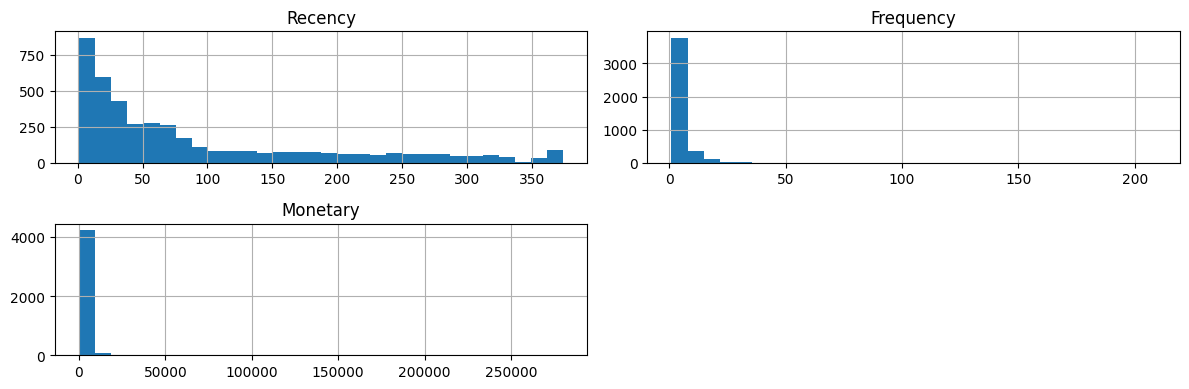

In [140]:
import matplotlib.pyplot as plt

# Visualiza a distribuição das três variáveis RFM
rfm[["Recency", "Frequency", "Monetary"]].hist(
    bins=30,
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

Principais achados: As três variáveis apresentam distribuições assimétricas, especialmente Frequency e Monetary. A maior parte dos clientes está concentrada em valores menores, enquanto poucos apresentam valores muito elevados. Por isso, é importante avaliar esses valores extremos antes de preparar os dados para o clustering.

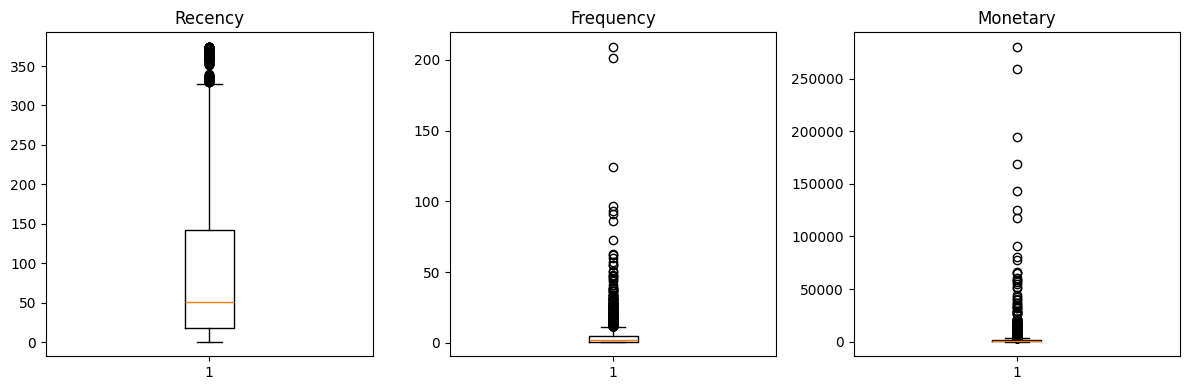

In [141]:
# Visualiza possíveis valores extremos nas variáveis RFM

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, coluna in zip(axes, ["Recency", "Frequency", "Monetary"]):
    ax.boxplot(rfm[coluna])
    ax.set_title(coluna)

plt.tight_layout()
plt.show()

Análise dos valores extremos: Os boxplots confirmam a presença de valores extremos, principalmente em Frequency e Monetary. Como esses valores podem representar clientes reais com comportamentos de compra diferentes, eles não serão removidos automaticamente. A preparação dos dados buscará reduzir seu impacto sem excluir esses clientes da análise.

In [142]:
# Clientes com os maiores valores de Monetary
print("Maiores valores de Monetary:")
display(
    rfm.sort_values("Monetary", ascending=False).head(10)
)

# Clientes com os maiores valores de Frequency
print("\nMaiores valores de Frequency:")
display(
    rfm.sort_values("Frequency", ascending=False).head(10)
)

Maiores valores de Monetary:


,CustomerID,Recency,Frequency,Monetary
1689,14646.0,2,73,280206.02
4201,18102.0,1,60,259657.30
3728,17450.0,8,46,194390.79
3008,16446.0,1,2,168472.50
1879,14911.0,1,201,143711.17
55,12415.0,24,21,124914.53
1333,14156.0,10,55,117210.08
3771,17511.0,3,31,91062.38
2702,16029.0,39,63,80850.84
0,12346.0,326,1,77183.60



Maiores valores de Frequency:


,CustomerID,Recency,Frequency,Monetary
326,12748.0,1,209,33053.19
1879,14911.0,1,201,143711.17
4010,17841.0,2,124,40519.84
562,13089.0,3,97,58762.08
1661,14606.0,1,93,12076.15
2176,15311.0,1,91,60632.75
481,12971.0,4,86,11189.91
1689,14646.0,2,73,280206.02
2702,16029.0,39,63,80850.84
795,13408.0,2,62,28117.04


Análise dos casos extremos: A inspeção mostrou que os maiores valores de Frequency e Monetary representam diferentes comportamentos de compra, como clientes muito frequentes, clientes de alto valor e clientes com poucas compras de valores elevados. Como esses casos podem representar comportamentos reais e relevantes para a segmentação, optou-se por mantê-los na análise e considerar sua influência na preparação dos dados.

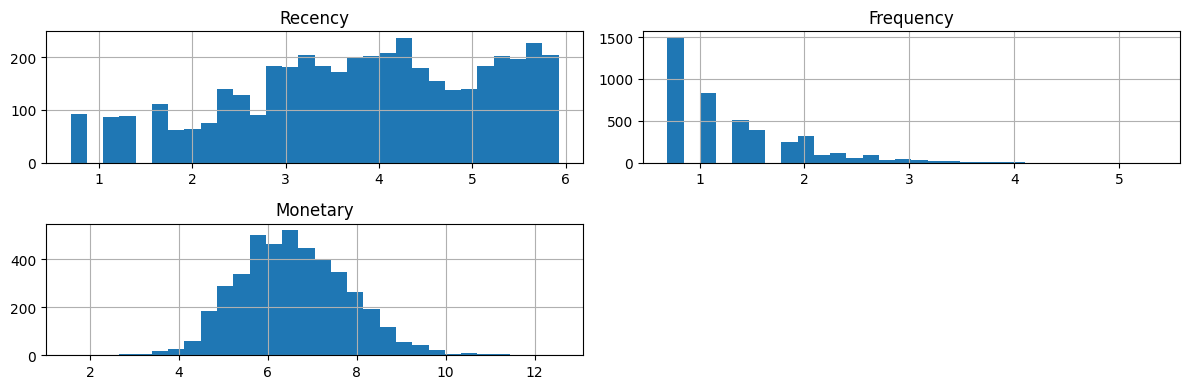

In [143]:
# Cria uma cópia das variáveis RFM para aplicar a transformação
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Aplica log(1 + x) para evitar problemas caso existam valores iguais a zero
rfm_log = np.log1p(rfm_log)

# Visualiza as distribuições após a transformação
rfm_log.hist(
    bins=30,
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

Resultado da transformação: A transformação logarítmica reduziu principalmente a assimetria de Monetary e a influência dos valores mais elevados. Frequency permaneceu assimétrica devido à concentração de clientes com poucas compras, característica presente na própria base.

In [144]:
from sklearn.preprocessing import StandardScaler

# Padroniza as variáveis transformadas
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

# Converte o resultado novamente para DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

# Verifica as primeiras linhas
rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


Padronização dos dados: Após a transformação logarítmica, as variáveis RFM foram padronizadas utilizando o StandardScaler. Dessa forma, Recency, Frequency e Monetary passaram a estar em uma escala comparável, evitando que diferenças de magnitude entre as variáveis tenham maior peso no cálculo das distâncias.

In [145]:
# Verifica o resultado da padronização
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


Resultado da preparação: Após a padronização, as três variáveis apresentaram média próxima de 0 e desvio-padrão igual a 1, confirmando que estão em uma escala comparável. A base está, portanto, preparada para a aplicação dos algoritmos de clustering.

5. Segmentação com K-Means

Nesta etapa, será aplicado o K-Means para agrupar clientes com perfis RFM semelhantes. Inicialmente, diferentes quantidades de clusters serão comparadas utilizando o método do cotovelo e o Silhouette Score.

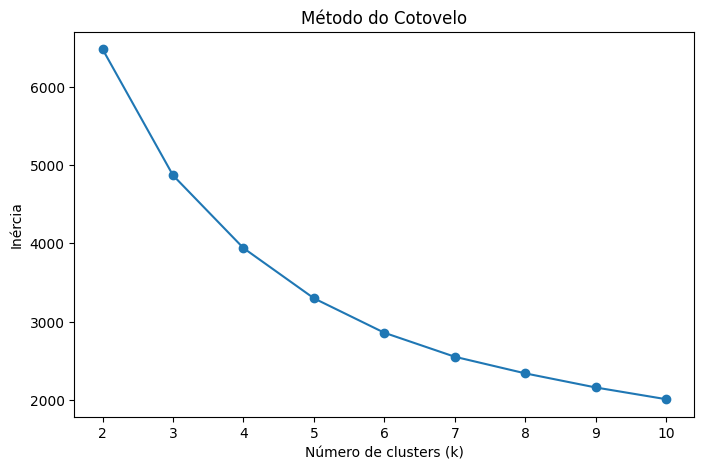

In [146]:
from sklearn.cluster import KMeans

# Valores de k que serão testados
valores_k = range(2, 11)

inercias = []

# Executa o K-Means para diferentes quantidades de clusters
for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inercias.append(kmeans.inertia_)

# Gráfico do método do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercias, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")

plt.xticks(valores_k)
plt.show()

Método do cotovelo: A redução da inércia é mais acentuada nos primeiros valores de k e passa a ocorrer de forma mais gradual à medida que novos clusters são adicionados. O gráfico sugere possíveis soluções próximas de 4 ou 5 clusters, mas não apresenta um ponto de corte totalmente evidente.

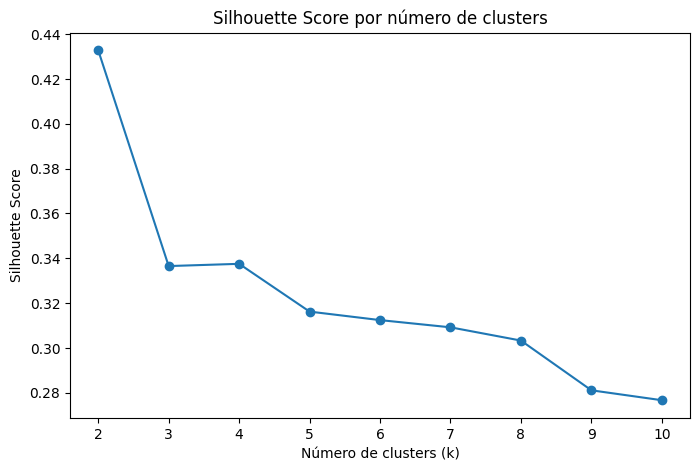

In [147]:
from sklearn.metrics import silhouette_score

silhouettes = []

# Calcula o Silhouette Score para cada valor de k
for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouettes.append(score)

# Gráfico do Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(valores_k, silhouettes, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")

plt.xticks(valores_k)
plt.show()

Silhouette Score: A solução com 2 clusters apresentou o maior Silhouette Score, indicando maior separação entre os grupos. As soluções com 3 e 4 clusters apresentaram resultados semelhantes entre si. Como a escolha não deve considerar apenas uma métrica, essas alternativas serão comparadas também pela composição e interpretação dos grupos.

Comparação das soluções

Como os métodos do cotovelo e Silhouette não apontaram para a mesma quantidade de clusters, serão comparadas as soluções com 2, 3, 4 e 5 grupos. Além das métricas, serão observados o tamanho e o perfil RFM dos clusters.

In [148]:
# Quantidades de clusters que serão comparadas
ks_comparar = [2, 3, 4, 5]

for k in ks_comparar:

    # Executa o K-Means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    # Cria uma cópia do RFM original para interpretação
    rfm_temp = rfm.copy()
    rfm_temp["Cluster"] = labels

    # Calcula o tamanho e as médias originais de cada cluster
    perfil = rfm_temp.groupby("Cluster").agg(
        Clientes=("CustomerID", "count"),
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        Monetary=("Monetary", "mean")
    ).round(2)

    print(f"\n--- Solução com k = {k} ---")
    display(perfil)


--- Solução com k = 2 ---


,Clientes,Recency,Frequency,Monetary
Cluster,,,,
0,2672,134.09,1.67,495.59
1,1666,25.89,8.44,4539.60



--- Solução com k = 3 ---


,Clientes,Recency,Frequency,Monetary
Cluster,,,,
0,769,17.06,13.35,7898.46
1,1872,167.36,1.35,361.00
2,1697,44.20,3.38,1259.58



--- Solução com k = 4 ---


,Clientes,Recency,Frequency,Monetary
Cluster,,,,
0,713,12.17,13.75,8088.02
1,1622,181.51,1.32,341.00
2,837,17.70,2.19,557.32
3,1166,71.64,4.08,1801.78



--- Solução com k = 5 ---


,Clientes,Recency,Frequency,Monetary
Cluster,,,,
0,834,26.99,1.64,389.58
1,938,18.51,5.84,2179.40
2,1209,208.35,1.21,277.22
3,1018,103.66,3.13,1452.36
4,339,12.16,20.75,13877.16


Escolha do número de clusters: Embora a solução com 2 clusters tenha apresentado o maior Silhouette Score, ela resultou em uma segmentação mais ampla dos clientes. A solução com 4 clusters permitiu identificar perfis RFM mais distintos e interpretáveis, mantendo um equilíbrio entre os resultados das métricas e a utilidade da segmentação. Por isso, foi selecionado k = 4 para o modelo K-Means.

In [149]:
# Modelo final de K-Means com 4 clusters
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Ajusta o modelo e identifica o cluster de cada cliente
clusters_kmeans = kmeans_final.fit_predict(rfm_scaled)

# Adiciona o cluster à base RFM original
rfm["Cluster_KMeans"] = clusters_kmeans

# Visualiza os primeiros resultados
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster_KMeans
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,2
4,12350.0,310,1,334.40,1


In [150]:
# Resume as características dos quatro clusters ("Em média, como são os clientes de cada cluster?")
perfil_kmeans = rfm.groupby("Cluster_KMeans").agg(
    Clientes=("CustomerID", "count"),
    Recency_Media=("Recency", "mean"),
    Frequency_Media=("Frequency", "mean"),
    Monetary_Medio=("Monetary", "mean")
).round(2)

perfil_kmeans

,Clientes,Recency_Media,Frequency_Media,Monetary_Medio
Cluster_KMeans,,,,
0,713,12.17,13.75,8088.02
1,1622,181.51,1.32,341.00
2,837,17.70,2.19,557.32
3,1166,71.64,4.08,1801.78


Perfil dos clusters: A solução com 4 clusters apresentou grupos com comportamentos distintos. Aqui a interpretação de cada um:


*   Cluster 0 (713 clientes): clientes mais recentes, frequentes e com maior gasto médio.
*   Cluster 1 (1.622 clientes): clientes com maior tempo desde a última compra, baixa frequência e menor gasto médio.

*  Cluster 2 (837 clientes): clientes que compraram recentemente, mas ainda apresentam baixa frequência e gasto.
*   Cluster 3 (1.166 clientes): clientes com comportamento intermediário em recência, frequência e gasto.





Estabilidade do K-Means

Para verificar a estabilidade da solução, o modelo com 4 clusters será executado utilizando diferentes sementes aleatórias. O objetivo é avaliar se diferentes inicializações produzem agrupamentos semelhantes.

In [151]:
from sklearn.metrics import adjusted_rand_score

# Diferentes sementes para testar a estabilidade
seeds = [10, 20, 30, 40, 50]

resultados = []

for seed in seeds:
    modelo = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )

    labels = modelo.fit_predict(rfm_scaled)

    # Compara cada solução com o modelo final (random_state=42)
    ari = adjusted_rand_score(clusters_kmeans, labels)

    resultados.append({
        "Seed": seed,
        "ARI": ari
    })

pd.DataFrame(resultados)

,Seed,ARI
0,10,0.929111
1,20,0.943949
2,30,0.935547
3,40,0.951953
4,50,0.940607


Estabilidade do modelo: O K-Means apresentou boa estabilidade entre diferentes inicializações, com valores de ARI entre 0,93 e 0,95. Isso indica que a composição dos clusters permaneceu bastante semelhante mesmo com a alteração da semente aleatória.

6. Clustering Hierárquico

Nesta etapa, será aplicado o clustering hierárquico utilizando diferentes métodos de ligação. Serão comparados Ward, Complete e Average, além da análise do dendrograma para avaliar a formação dos grupos.

In [152]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

metodos = ["ward", "complete", "average"]

resultados_hierarquico = []

for metodo in metodos:

    modelo = AgglomerativeClustering(
        n_clusters=4,
        linkage=metodo
    )

    labels = modelo.fit_predict(rfm_scaled)

    silhouette = silhouette_score(rfm_scaled, labels)

    resultados_hierarquico.append({
        "Método": metodo,
        "Silhouette": silhouette
    })

pd.DataFrame(resultados_hierarquico)

,Método,Silhouette
0,ward,0.279991
1,complete,0.375472
2,average,0.431648


Comparação dos métodos: O método Average apresentou o maior Silhouette Score (0,432), seguido por Complete (0,375) e Ward (0,280). Esse resultado indica uma melhor separação dos clusters pelo método Average. No entanto, a escolha também será avaliada considerando o dendrograma e a composição dos grupos.

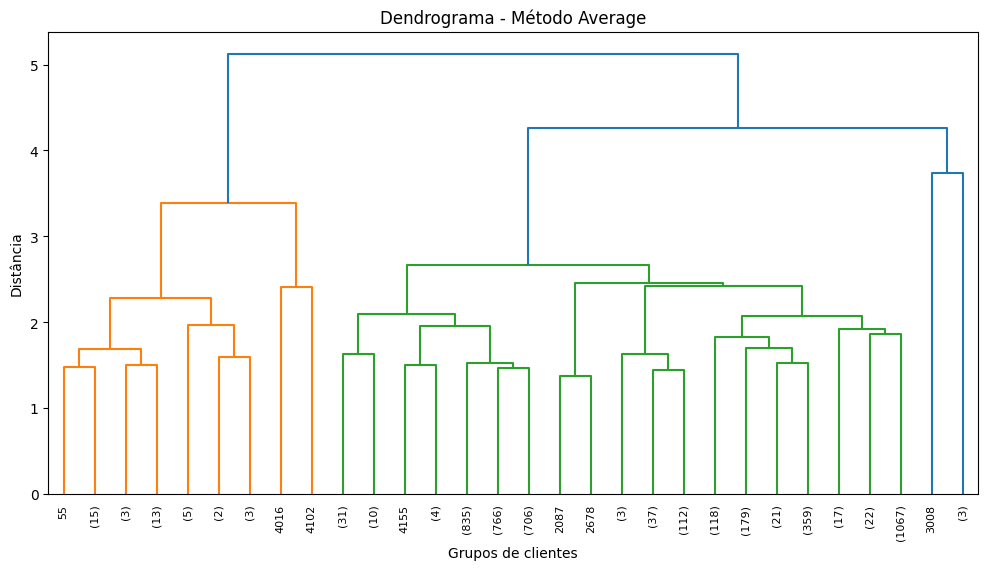

In [153]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Calcula a hierarquia utilizando o método Average
Z_average = linkage(rfm_scaled, method="average")

# Dendrograma
plt.figure(figsize=(12, 6))

dendrogram(
    Z_average,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrograma - Método Average")
plt.xlabel("Grupos de clientes")
plt.ylabel("Distância")
plt.show()

Análise do dendrograma: O dendrograma do método Average mostra a formação progressiva dos agrupamentos e apresenta aumentos de distância nas etapas finais de união dos grupos. Entretanto, não há um ponto de corte único e claramente definido, indicando que a escolha da quantidade de clusters deve considerar também as métricas de avaliação e a interpretação dos grupos.

In [154]:
# Modelo hierárquico usando Average e 4 clusters
hierarquico_average = AgglomerativeClustering(
    n_clusters=4,
    linkage="average"
)

clusters_hierarquico = hierarquico_average.fit_predict(rfm_scaled)

# Adiciona os clusters à base RFM
rfm["Cluster_Hierarquico"] = clusters_hierarquico

# Perfil médio dos clusters
perfil_hierarquico = rfm.groupby("Cluster_Hierarquico").agg(
    Clientes=("CustomerID", "count"),
    Recency_Media=("Recency", "mean"),
    Frequency_Media=("Frequency", "mean"),
    Monetary_Medio=("Monetary", "mean")
).round(2)

perfil_hierarquico

,Clientes,Recency_Media,Frequency_Media,Monetary_Medio
Cluster_Hierarquico,,,,
0,44,16.07,50.43,56666.05
1,3,247.67,2.33,53878.13
2,4290,93.23,3.80,1413.47
3,1,1.00,2.00,168472.50


Comparação do perfil dos métodos hierárquicos

Embora o método Average tenha apresentado o maior Silhouette Score, seus clusters ficaram muito desequilibrados. Por isso, serão analisados também os perfis gerados pelos métodos Ward e Complete, buscando uma solução que combine qualidade do agrupamento e melhor distribuição dos clientes.

In [155]:
for metodo in ["ward", "complete"]:

    modelo = AgglomerativeClustering(
        n_clusters=4,
        linkage=metodo
    )

    labels = modelo.fit_predict(rfm_scaled)

    rfm_temp = rfm.copy()
    rfm_temp["Cluster"] = labels

    perfil = rfm_temp.groupby("Cluster").agg(
        Clientes=("CustomerID", "count"),
        Recency_Media=("Recency", "mean"),
        Frequency_Media=("Frequency", "mean"),
        Monetary_Medio=("Monetary", "mean")
    ).round(2)

    print(f"\n--- Método {metodo.upper()} ---")
    display(perfil)


--- Método WARD ---


,Clientes,Recency_Media,Frequency_Media,Monetary_Medio
Cluster,,,,
0,1716,146.58,1.26,270.31
1,762,9.69,5.46,1811.13
2,1517,91.01,3.46,1558.66
3,343,13.00,20.28,13640.80



--- Método COMPLETE ---


,Clientes,Recency_Media,Frequency_Media,Monetary_Medio
Cluster,,,,
0,1820,36.25,6.78,2746.83
1,2467,135.59,1.55,430.10
2,47,4.60,50.09,53123.48
3,4,186.00,2.25,82526.73


Comparação dos métodos: Apesar de apresentar menor Silhouette Score, o método Ward produziu uma distribuição mais equilibrada dos clientes entre os quatro clusters. Os métodos Average e Complete apresentaram grupos muito pequenos e maior concentração de clientes em poucos clusters. Por isso, o Ward foi selecionado como a solução hierárquica mais adequada, considerando conjuntamente a métrica, o tamanho dos grupos e sua interpretabilidade.

7. Segmentação com DBSCAN

Como terceiro algoritmo, será utilizado o DBSCAN, que identifica clusters a partir da densidade dos dados e permite classificar observações isoladas como ruído. Diferentemente do K-Means e do clustering hierárquico, não é necessário definir previamente o número de clusters.

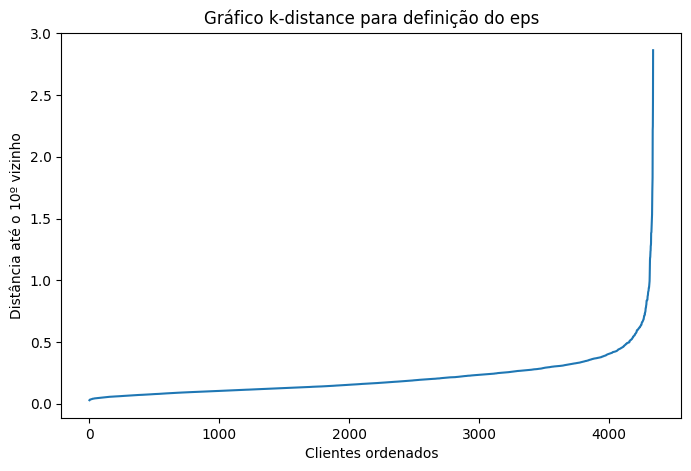

In [156]:
from sklearn.neighbors import NearestNeighbors

# Número de vizinhos utilizado na análise
min_samples = 10

# Calcula a distância para os vizinhos mais próximos
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(rfm_scaled)

distancias, indices = neighbors_fit.kneighbors(rfm_scaled)

# Distância até o 10º vizinho de cada cliente
k_distancias = np.sort(distancias[:, -1])

# Gráfico k-distance
plt.figure(figsize=(8, 5))
plt.plot(k_distancias)
plt.xlabel("Clientes ordenados")
plt.ylabel("Distância até o 10º vizinho")
plt.title("Gráfico k-distance para definição do eps")
plt.show()

Definição do eps: O gráfico k-distance apresenta um aumento mais acentuado das distâncias aproximadamente entre 0,4 e 0,6. Essa região foi utilizada como referência para testar diferentes valores de eps antes da definição do modelo final.

In [157]:
from sklearn.cluster import DBSCAN

valores_eps = [0.4, 0.5, 0.6]

resultados_dbscan = []

for eps in valores_eps:

    modelo = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = modelo.fit_predict(rfm_scaled)

    # Número de clusters, desconsiderando o rótulo -1 (ruído)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Quantidade de clientes classificados como ruído
    n_ruidos = np.sum(labels == -1)

    resultados_dbscan.append({
        "eps": eps,
        "Clusters": n_clusters,
        "Ruídos": n_ruidos,
        "% Ruído": (n_ruidos / len(labels)) * 100
    })

pd.DataFrame(resultados_dbscan).round(2)

,eps,Clusters,Ruídos,% Ruído
0,0.4,3,166,3.83
1,0.5,2,79,1.82
2,0.6,1,50,1.15


Comparação dos valores de eps: O aumento do eps reduziu tanto o número de clusters quanto a quantidade de clientes classificados como ruído. Com eps = 0,6, praticamente todos os clientes foram agrupados em um único cluster. Por isso, as soluções com eps = 0,4 e 0,5 serão analisadas com mais detalhe.

In [158]:
for eps in [0.4, 0.5]:

    modelo = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = modelo.fit_predict(rfm_scaled)

    print(f"\n--- eps = {eps} ---")
    print(pd.Series(labels).value_counts().sort_index())


--- eps = 0.4 ---
-1     166
 0    1887
 1    1464
 2     821
Name: count, dtype: int64

--- eps = 0.5 ---
-1      79
 0    2780
 1    1479
Name: count, dtype: int64


Distribuição dos clusters: A solução com eps = 0,4 apresentou três clusters com tamanhos relativamente equilibrados e classificou 166 clientes (3,83%) como ruído. Já com eps = 0,5, os clientes foram concentrados em apenas dois grupos. Por isso, eps = 0,4 foi selecionado para a solução DBSCAN.

In [159]:
# Modelo DBSCAN selecionado
dbscan_final = DBSCAN(
    eps=0.4,
    min_samples=10
)

clusters_dbscan = dbscan_final.fit_predict(rfm_scaled)

# Identifica apenas os clientes pertencentes aos clusters
mascara_clusters = clusters_dbscan != -1

# Silhouette sem considerar os ruídos
silhouette_dbscan = silhouette_score(
    rfm_scaled[mascara_clusters],
    clusters_dbscan[mascara_clusters]
)

print("Silhouette DBSCAN:", round(silhouette_dbscan, 4))

Silhouette DBSCAN: 0.1748


Avaliação do DBSCAN: O modelo apresentou Silhouette Score de 0,175, indicando baixa separação entre os clusters. Antes de comparar o DBSCAN com os demais algoritmos, será analisado o perfil RFM dos grupos encontrados e dos clientes classificados como ruído.

In [160]:
# Adiciona o resultado do DBSCAN à base RFM
rfm["Cluster_DBSCAN"] = clusters_dbscan

# Perfil dos clusters e dos clientes classificados como ruído
perfil_dbscan = rfm.groupby("Cluster_DBSCAN").agg(
    Clientes=("CustomerID", "count"),
    Recency_Media=("Recency", "mean"),
    Frequency_Media=("Frequency", "mean"),
    Monetary_Medio=("Monetary", "mean")
).round(2)

perfil_dbscan

,Clientes,Recency_Media,Frequency_Media,Monetary_Medio
Cluster_DBSCAN,,,,
-1,166,60.61,20.27,20862.19
0,1887,43.84,6.39,2329.90
1,1464,157.99,1.00,340.60
2,821,94.20,2.00,644.25


Perfil dos clusters — DBSCAN:

*   Cluster 0 (1.887): clientes relativamente recentes, mais frequentes e com maior gasto entre os clusters identificados.
*   Cluster 1 (1.464): clientes com apenas uma compra, maior recência e baixo gasto.


*   Cluster 2 (821): clientes com duas compras e comportamento intermediário de recência e gasto.
*  Ruído (166): clientes com comportamentos mais extremos, principalmente em frequência e valor gasto.





Apesar de apresentar grupos interpretáveis e identificar clientes com comportamento extremo, o baixo Silhouette Score (0,175) indica que os clusters encontrados pelo DBSCAN apresentam baixa separação.

8. Comparação dos algoritmos

Nesta etapa, as soluções obtidas com K-Means, clustering hierárquico e DBSCAN serão comparadas por diferentes métricas de avaliação. A escolha da solução final também considerará a distribuição dos clientes e a interpretabilidade dos clusters.

In [161]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Labels do Hierárquico Ward
hierarquico_final = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

clusters_ward = hierarquico_final.fit_predict(rfm_scaled)

# Função para calcular as métricas
def calcular_metricas(dados, labels):
    return {
        "Silhouette": silhouette_score(dados, labels),
        "Davies-Bouldin": davies_bouldin_score(dados, labels),
        "Calinski-Harabasz": calinski_harabasz_score(dados, labels)
    }

# K-Means
metricas_kmeans = calcular_metricas(
    rfm_scaled,
    clusters_kmeans
)

# Hierárquico Ward
metricas_ward = calcular_metricas(
    rfm_scaled,
    clusters_ward
)

# DBSCAN - excluindo os ruídos
metricas_dbscan = calcular_metricas(
    rfm_scaled[mascara_clusters],
    clusters_dbscan[mascara_clusters]
)

comparacao_metricas = pd.DataFrame(
    [metricas_kmeans, metricas_ward, metricas_dbscan],
    index=["K-Means", "Hierárquico Ward", "DBSCAN"]
).round(3)

comparacao_metricas

,Silhouette,Davies-Bouldin,Calinski-Harabasz
K-Means,0.338,1.009,3328.338
Hierárquico Ward,0.280,1.099,2739.570
DBSCAN,0.175,1.689,2079.212


Comparação dos algoritmos: O K-Means apresentou o melhor desempenho nas três métricas avaliadas, com maior Silhouette e Calinski-Harabasz e menor Davies-Bouldin. Além disso, apresentou clusters relativamente equilibrados e com perfis RFM distintos e interpretáveis. O método hierárquico Ward apresentou desempenho intermediário, enquanto o DBSCAN apresentou menor separação entre os grupos. Considerando conjuntamente as métricas e a interpretação dos clusters, o K-Means com 4 clusters foi selecionado como solução final.

9. Redução de dimensionalidade com PCA

Nesta etapa, será aplicado o PCA às variáveis RFM padronizadas para avaliar a variância explicada pelos componentes principais e facilitar a visualização dos clusters obtidos pelo K-Means.

In [162]:
from sklearn.decomposition import PCA

# PCA com os três componentes possíveis
pca = PCA(n_components=3)
pca_resultado = pca.fit_transform(rfm_scaled)

# Variância explicada por cada componente
variancia_pca = pd.DataFrame({
    "Componente": ["PC1", "PC2", "PC3"],
    "Variância Explicada": pca.explained_variance_ratio_,
    "Variância Acumulada": np.cumsum(pca.explained_variance_ratio_)
})

variancia_pca.round(4)

,Componente,Variância Explicada,Variância Acumulada
0,PC1,0.7508,0.7508
1,PC2,0.1879,0.9387
2,PC3,0.0613,1.0000


Interpretação dos componentes principais

Para compreender o significado dos componentes principais, serão analisados os loadings de Recency, Frequency e Monetary. Valores maiores, em módulo, indicam maior contribuição da variável para o componente.

In [163]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=["Recency", "Frequency", "Monetary"]
)

loadings.round(3)

,PC1,PC2,PC3
Recency,-0.512,0.850,0.127
Frequency,0.618,0.261,0.741
Monetary,0.597,0.458,-0.659


Interpretação dos componentes: O PC1 apresentou maiores contribuições positivas de Frequency e Monetary e negativa de Recency, representando principalmente clientes mais recentes, frequentes e de maior valor. O PC2 foi predominantemente associado à Recency. Juntos, os dois componentes explicam 93,87% da variância, permitindo representar a maior parte da informação RFM em duas dimensões.

Visualização dos clusters com PCA

Como os dois primeiros componentes preservam 93,87% da variância, eles serão utilizados para representar os quatro clusters do K-Means em duas dimensões. O PC1 está associado principalmente à atividade e ao valor dos clientes, enquanto o PC2 apresenta maior contribuição da recência.

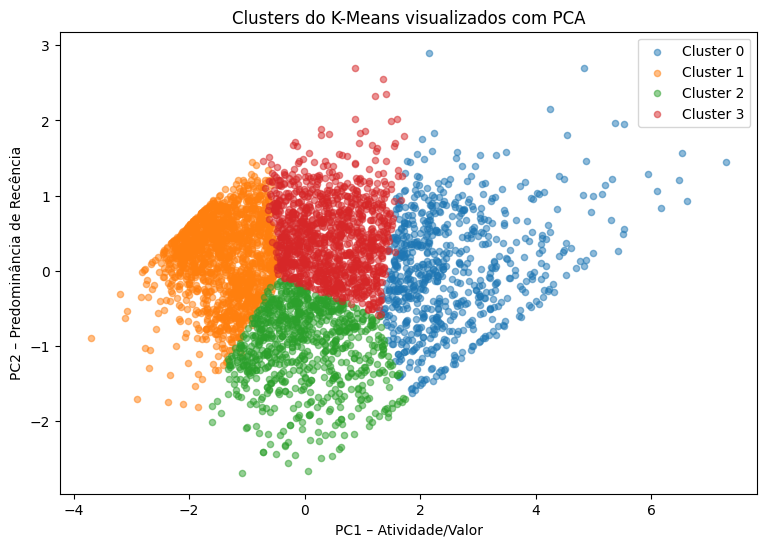

In [164]:
# Cria uma base com as coordenadas dos clientes no PCA
pca_df = pd.DataFrame(
    pca_resultado[:, :2],
    columns=["PC1", "PC2"],
    index=rfm.index
)

# Adiciona o cluster do K-Means
pca_df["Cluster"] = rfm["Cluster_KMeans"]

# Visualização
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    dados_cluster = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        dados_cluster["PC1"],
        dados_cluster["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5,
        s=20
    )

plt.xlabel("PC1 – Atividade/Valor")
plt.ylabel("PC2 – Predominância de Recência")
plt.title("Clusters do K-Means visualizados com PCA")
plt.legend()
plt.show()

Visualização dos clusters: A projeção em duas dimensões, que preserva 93,87% da variância, evidencia regiões distintas para os quatro clusters do K-Means, embora exista alguma proximidade entre os grupos nas regiões de fronteira. O PC1 diferencia principalmente os clientes em relação à atividade e valor, contribuindo para a separação visual dos perfis identificados.

Visualização tridimensional dos clusters

A visualização em três dimensões utiliza os três componentes principais e preserva 100% da variância das variáveis RFM. O objetivo é complementar a análise visual da separação dos quatro clusters do K-Means.

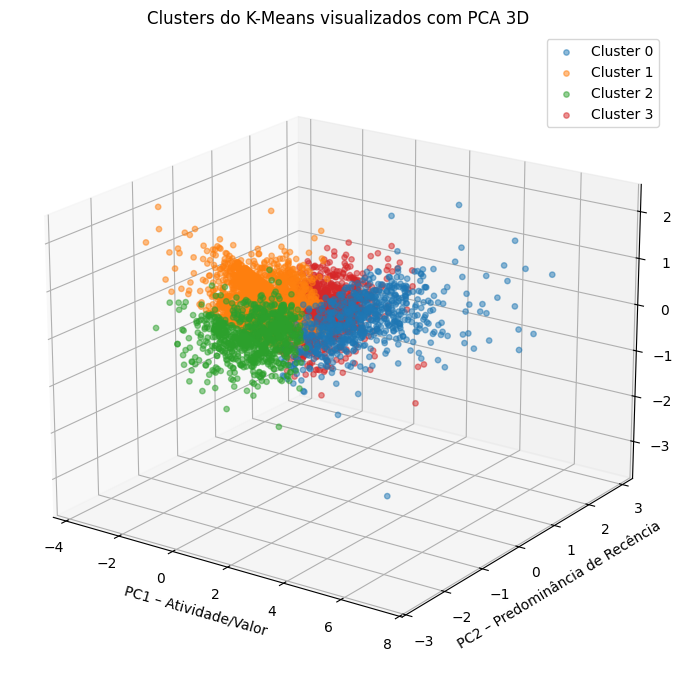

In [165]:
from mpl_toolkits.mplot3d import Axes3D

# Base com os três componentes
pca_3d = pd.DataFrame(
    pca_resultado,
    columns=["PC1", "PC2", "PC3"],
    index=rfm.index
)

pca_3d["Cluster"] = rfm["Cluster_KMeans"]

# Gráfico 3D
fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(pca_3d["Cluster"].unique()):
    dados_cluster = pca_3d[pca_3d["Cluster"] == cluster]

    ax.scatter(
        dados_cluster["PC1"],
        dados_cluster["PC2"],
        dados_cluster["PC3"],
        label=f"Cluster {cluster}",
        alpha=0.5,
        s=15
    )

ax.set_xlabel("PC1 – Atividade/Valor")
ax.set_ylabel("PC2 – Predominância de Recência")
ax.set_zlabel("PC3", labelpad=8)
ax.set_title("Clusters do K-Means visualizados com PCA 3D")
ax.legend()

# Ajusta manualmente as margens da figura
plt.subplots_adjust(
    left=0.05,
    right=0.80,
    bottom=0.08,
    top=0.90
)


ax.view_init(elev=20, azim=-55)
ax.set_position([0.05, 0.08, 0.72, 0.82])

plt.show()

Visualização 3D: A inclusão do terceiro componente permite representar 100% da variância dos dados e mantém o padrão de separação observado em duas dimensões. Como o PC3 acrescenta apenas 6,13% da variância, a visualização 2D já representa adequadamente a maior parte da estrutura dos dados.

Visualização dos centroides

Os centroides representam o centro de cada cluster identificado pelo K-Means. Para complementar a visualização, eles serão projetados junto aos clientes no espaço formado pelos dois primeiros componentes principais.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names



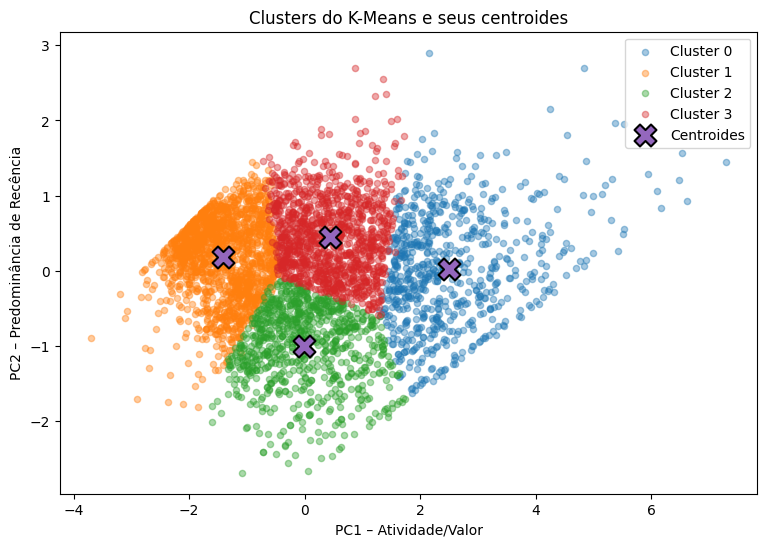

In [166]:
# Projeta os centroides do K-Means no espaço do PCA
centroides_pca = pca.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(9, 6))

# Clientes de cada cluster
for cluster in sorted(pca_df["Cluster"].unique()):
    dados_cluster = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        dados_cluster["PC1"],
        dados_cluster["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.4,
        s=20
    )

# Centroides
plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    label="Centroides"
)

plt.xlabel("PC1 – Atividade/Valor")
plt.ylabel("PC2 – Predominância de Recência")
plt.title("Clusters do K-Means e seus centroides")
plt.legend()
plt.show()

Centroides dos clusters: Os centroides ocupam regiões distintas no espaço formado pelos dois primeiros componentes principais e representam o perfil central de cada cluster. A visualização reforça a diferenciação dos quatro grupos identificados pelo K-Means.

10. Caracterização visual dos clusters

Nesta etapa, serão utilizadas diferentes visualizações para comparar os perfis dos quatro clusters selecionados pelo K-Means e facilitar sua interpretação em termos de Recency, Frequency e Monetary.

In [167]:
# Adiciona os clusters à base padronizada
rfm_scaled_clusters = rfm_scaled.copy()
rfm_scaled_clusters["Cluster"] = rfm["Cluster_KMeans"].values

# Média padronizada de cada variável por cluster
perfil_padronizado = (
    rfm_scaled_clusters
    .groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

perfil_padronizado.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,-1.24,1.66,1.41
1,0.88,-0.78,-0.80
2,-0.86,-0.35,-0.39
3,0.15,0.32,0.53


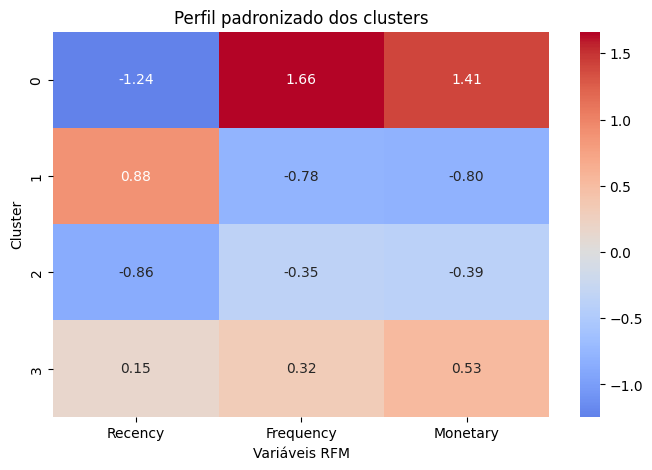

In [168]:
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.heatmap(
    perfil_padronizado,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Perfil padronizado dos clusters")
plt.xlabel("Variáveis RFM")
plt.ylabel("Cluster")
plt.show()

Perfil dos clusters: O heatmap evidencia diferenças claras entre os quatro grupos. O Cluster 0 apresenta maior frequência e valor, além de compras mais recentes. O Cluster 1 apresenta menor frequência e valor e maior tempo desde a última compra. O Cluster 2 reúne clientes recentes, mas ainda com menor frequência e valor. Já o Cluster 3 apresenta um perfil intermediário, com frequência e valor acima da média.

Distribuição dos clientes entre os clusters

A quantidade de clientes em cada cluster será analisada para verificar a representatividade dos diferentes segmentos identificados pelo K-Means.

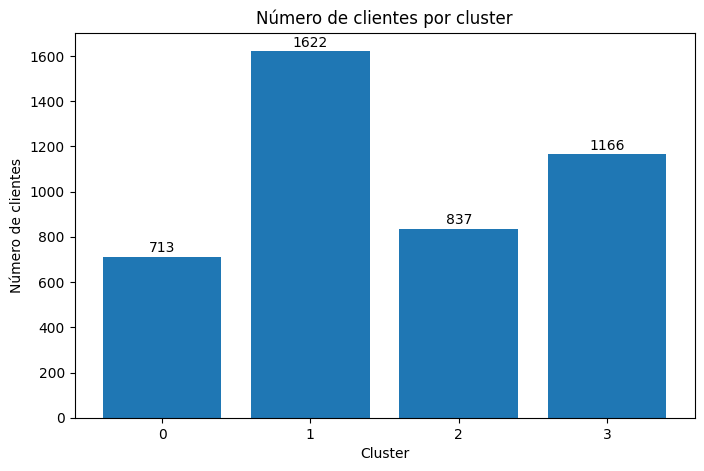

In [169]:
tamanho_clusters = (
    rfm["Cluster_KMeans"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    tamanho_clusters.index.astype(str),
    tamanho_clusters.values
)

plt.xlabel("Cluster")
plt.ylabel("Número de clientes")
plt.title("Número de clientes por cluster")

# Mostra o número acima de cada barra
for i, valor in enumerate(tamanho_clusters.values):
    plt.text(i, valor + 20, str(valor), ha="center")

plt.show()

Distribuição dos clusters: Os quatro clusters apresentam tamanhos distintos, mas todos representam parcelas relevantes da base, sem a formação de grupos extremamente pequenos. O Cluster 1 concentra o maior número de clientes, seguido pelos Clusters 3, 2 e 0.

Distribuição do valor gasto por cluster

Para complementar a caracterização dos segmentos, será analisada a distribuição do valor total gasto (Monetary) pelos clientes de cada cluster.

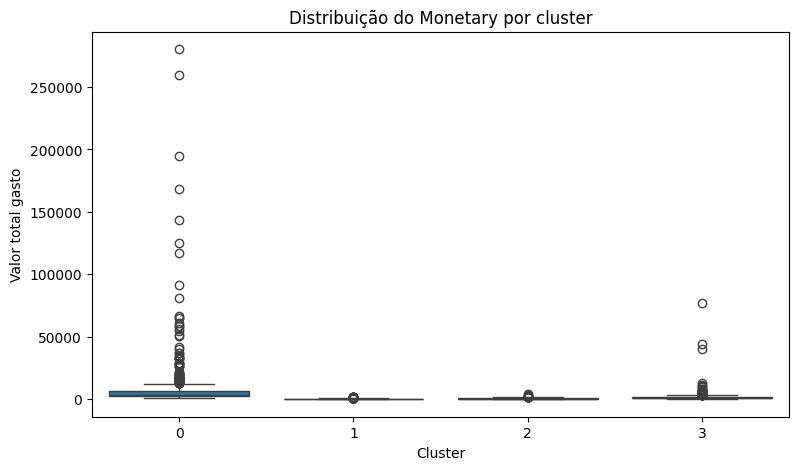

In [170]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=rfm,
    x="Cluster_KMeans",
    y="Monetary"
)

plt.xlabel("Cluster")
plt.ylabel("Valor total gasto")
plt.title("Distribuição do Monetary por cluster")
plt.show()

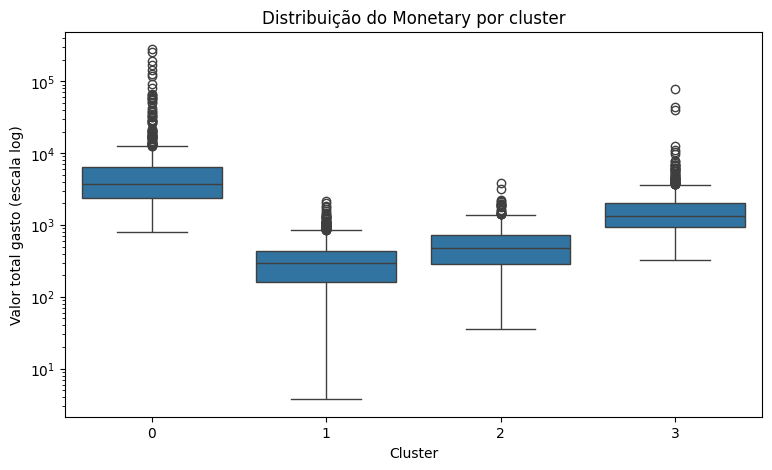

In [171]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=rfm,
    x="Cluster_KMeans",
    y="Monetary"
)

# Escala logarítmica apenas para facilitar a visualização
plt.yscale("log")

plt.xlabel("Cluster")
plt.ylabel("Valor total gasto (escala log)")
plt.title("Distribuição do Monetary por cluster")
plt.show()

Distribuição do gasto: O Cluster 0 apresenta os maiores valores de gasto e também maior variabilidade, incluindo clientes de valor bastante elevado. O Cluster 1 apresenta os menores gastos, seguido pelo Cluster 2, enquanto o Cluster 3 ocupa uma posição intermediária. A escala logarítmica foi utilizada apenas para facilitar a visualização dos valores extremos.

Contribuição dos clusters para a receita

Além do comportamento individual dos clientes, será analisada a participação de cada cluster no valor total gasto, permitindo identificar quais segmentos apresentam maior contribuição para a receita.

In [172]:
receita_clusters = (
    rfm.groupby("Cluster_KMeans")["Monetary"]
    .sum()
)

percentual_receita = (
    receita_clusters / receita_clusters.sum() * 100
)

percentual_receita.round(2)

,Monetary
Cluster_KMeans,
0,64.89
1,6.22
2,5.25
3,23.64


Contribuição para a receita: O Cluster 0 se destaca por concentrar 64,89% do valor total gasto, apesar de representar uma parcela menor dos clientes. O Cluster 3 responde por 23,64%, enquanto os Clusters 1 e 2 apresentam participações bem menores, de 6,22% e 5,25%, respectivamente.

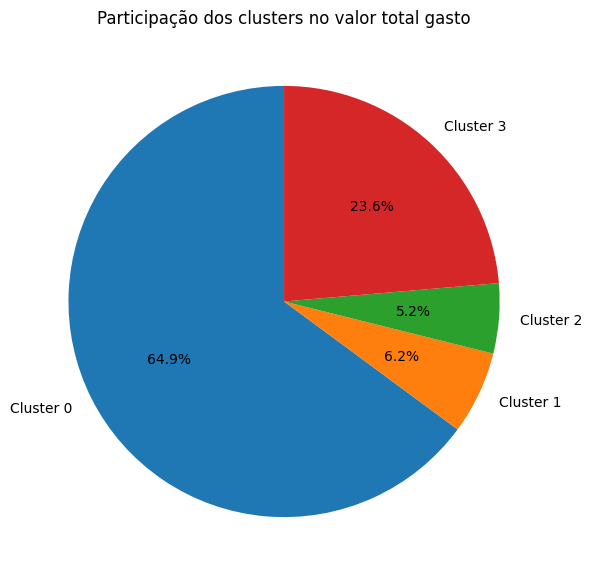

In [173]:
plt.figure(figsize=(7, 7))

plt.pie(
    percentual_receita.values,
    labels=[f"Cluster {i}" for i in percentual_receita.index],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Participação dos clusters no valor total gasto")
plt.show()

Comparação dos perfis em gráfico radar

O gráfico radar será utilizado para comparar simultaneamente as características de Recency, Frequency e Monetary dos quatro clusters. Para permitir a comparação entre as variáveis, serão utilizados os valores padronizados dos perfis.

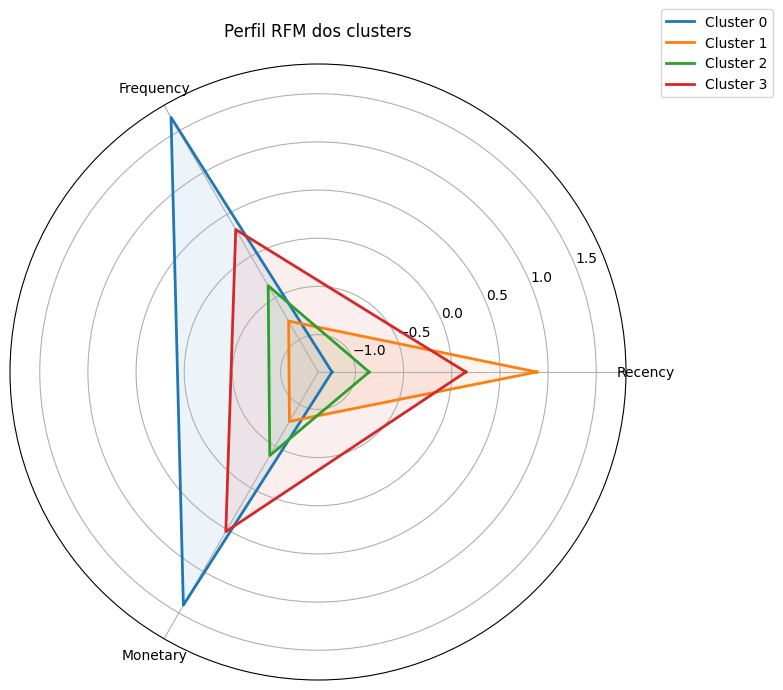

In [174]:
# Variáveis utilizadas no radar
categorias = ["Recency", "Frequency", "Monetary"]

# Número de variáveis
N = len(categorias)

# Ângulos de cada eixo
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster in perfil_padronizado.index:

    valores = perfil_padronizado.loc[cluster, categorias].tolist()
    valores += valores[:1]

    ax.plot(
        angulos,
        valores,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

    ax.fill(
        angulos,
        valores,
        alpha=0.08
    )

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias)

ax.set_title("Perfil RFM dos clusters", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

plt.show()

Perfil RFM dos clusters: O gráfico radar reforça as diferenças entre os segmentos. O Cluster 0 se destaca pela maior frequência e valor gasto, enquanto o Cluster 1 apresenta menor frequência e valor e maior tempo desde a última compra. O Cluster 2 reúne clientes mais recentes, porém com menor frequência e gasto, e o Cluster 3 apresenta comportamento intermediário. Em Recency, valores maiores indicam maior tempo desde a última compra.

11. Interpretação dos segmentos

A partir dos perfis RFM, do tamanho dos clusters e de sua contribuição para o valor total gasto, os quatro grupos foram caracterizados de forma descritiva. Os nomes atribuídos buscam facilitar a interpretação dos segmentos sem assumir que representam categorias naturais ou permanentes de clientes.

| Cluster | Clientes | Perfil                                                    |    Receita | Nome sugerido                    |
| ------- | -------: | --------------------------------------------------------- | ---------: | -------------------------------- |
| **0**   |      713 | Muito recentes, muito frequentes e alto gasto             | **64,89%** | **Alto valor**                   |
| **1**   |    1.622 | Menos recentes, baixa frequência e baixo gasto            |  **6,22%** | **Pouco ativos**                 |
| **2**   |      837 | Recentes, baixa frequência e baixo gasto                  |  **5,25%** | **Recentes de baixa frequência** |
| **3**   |    1.166 | Recência intermediária, frequência e gasto acima da média | **23,64%** | **Intermediários**               |


Interpretação dos segmentos:


*   Alto valor (Cluster 0): clientes recentes, muito frequentes e de alto gasto. Apesar de representar uma parcela menor da base, concentra 64,89% do valor total gasto.

*   Pouco ativos (Cluster 1): maior grupo da base, caracterizado por maior tempo desde a última compra, baixa frequência e baixo gasto.

*   Recentes de baixa frequência (Cluster 2): clientes que compraram recentemente, mas ainda apresentam poucas compras e menor valor gasto.

*   Intermediários (Cluster 3): apresentam frequência e gasto acima da média, mas ainda abaixo do perfil observado no grupo de alto valor.

Síntese de negócio: Os resultados indicam oportunidades distintas de retenção, reativação e desenvolvimento dos clientes. Destaca-se a concentração de 64,89% do valor gasto no Cluster 0, enquanto o comportamento recente do Cluster 2 sugere oportunidade de aumento de frequência e valor. As recomendações devem ser entendidas como hipóteses de ação derivadas dos padrões observados, e não como relações causais.

12. Limitações da análise

Apesar de permitir identificar padrões relevantes de comportamento, a segmentação apresenta algumas limitações:

* RFM resume o comportamento: Recency considera apenas a última compra, enquanto Frequency e Monetary agregam todo o período. Assim, diferentes trajetórias de compra podem resultar em perfis RFM semelhantes.

* Clusters não representam categorias naturais: os grupos são padrões estatísticos encontrados nos dados e não tipos fixos de clientes.

* Escolha do número de clusters: embora diferentes métricas tenham sido avaliadas, a escolha de quatro clusters também considerou interpretabilidade e utilidade prática, não existindo necessariamente um único número “correto” de grupos.

* Valores extremos: clientes com frequência ou gasto muito elevados foram mantidos por poderem representar comportamentos legítimos, mesmo influenciando a estrutura dos dados.

* Período analisado: os resultados representam o comportamento observado entre dezembro de 2010 e dezembro de 2011 e podem mudar em outros períodos.

* Recomendações não indicam causalidade: os clusters ajudam a identificar padrões e hipóteses de ação, mas não demonstram que determinada estratégia causará mudança no comportamento dos clientes.

13. Dashboard Interativo dos Clusters

Para facilitar a exploração dos resultados da segmentação, foi desenvolvido um dashboard interativo utilizando Plotly. A visualização apresenta o tamanho dos clusters, o perfil médio das variáveis RFM e a distribuição dos clientes no espaço reduzido pelo PCA.

In [175]:
import plotly.express as px
import plotly.graph_objects as go

In [176]:
# Quantidade de clientes em cada cluster
tamanho_clusters = (
    rfm["Cluster_KMeans"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tamanho_clusters.columns = ["Cluster", "Clientes"]

# Nomes dos segmentos
nomes_clusters = {
    0: "Clientes de alto valor",
    1: "Clientes pouco ativos",
    2: "Clientes recentes de baixa frequência",
    3: "Clientes intermediários"
}

tamanho_clusters["Segmento"] = tamanho_clusters["Cluster"].map(nomes_clusters)

# Gráfico interativo
fig = px.bar(
    tamanho_clusters,
    x="Segmento",
    y="Clientes",
    text="Clientes",
    title="Quantidade de clientes por segmento",
    labels={
        "Segmento": "Segmento",
        "Clientes": "Número de clientes"
    }
)

fig.update_layout(
    xaxis_tickangle=-20
)

fig.show()

In [177]:
# Cria uma base com os valores padronizados e os clusters do K-Means
rfm_dashboard = rfm_scaled.copy()
rfm_dashboard["Cluster"] = rfm["Cluster_KMeans"].values

# Calcula o perfil médio padronizado de cada cluster
perfil_dashboard = (
    rfm_dashboard
    .groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .reset_index()
)

# Adiciona os nomes dos segmentos
perfil_dashboard["Segmento"] = perfil_dashboard["Cluster"].map(nomes_clusters)

# Transforma a tabela para o formato adequado ao Plotly
perfil_long = perfil_dashboard.melt(
    id_vars=["Cluster", "Segmento"],
    value_vars=["Recency", "Frequency", "Monetary"],
    var_name="Indicador",
    value_name="Valor padronizado"
)

# Gráfico interativo
fig = px.bar(
    perfil_long,
    x="Indicador",
    y="Valor padronizado",
    color="Segmento",
    barmode="group",
    title="Perfil RFM dos segmentos",
    labels={"Valor padronizado": "Valor médio padronizado"}
)

fig.show()

In [178]:
from sklearn.decomposition import PCA

# PCA com 2 componentes para visualização
pca_dashboard_model = PCA(n_components=2)
dados_pca = pca_dashboard_model.fit_transform(rfm_scaled)

# Base para o gráfico interativo
pca_dashboard = pd.DataFrame({
    "PC1": dados_pca[:, 0],
    "PC2": dados_pca[:, 1],
    "Cluster": rfm["Cluster_KMeans"].values,
    "CustomerID": rfm["CustomerID"].values,
    "Recency": rfm["Recency"].values,
    "Frequency": rfm["Frequency"].values,
    "Monetary": rfm["Monetary"].values
})

# Nome dos segmentos
pca_dashboard["Segmento"] = pca_dashboard["Cluster"].map(nomes_clusters)

# Gráfico PCA interativo
fig = px.scatter(
    pca_dashboard,
    x="PC1",
    y="PC2",
    color="Segmento",
    hover_data={
        "CustomerID": True,
        "Recency": True,
        "Frequency": True,
        "Monetary": ":.2f"
    },
    title="Visualização interativa dos clusters - PCA",
    labels={
        "PC1": "Componente Principal 1",
        "PC2": "Componente Principal 2",
        "Segmento": "Segmento"
    },
    opacity=0.65
)

fig.update_traces(marker=dict(size=6))

fig.show()

In [179]:
# Calcula o valor total gasto por segmento
receita_clusters = (
    rfm.groupby("Cluster_KMeans")["Monetary"]
    .sum()
    .reset_index()
)

receita_clusters["Segmento"] = receita_clusters["Cluster_KMeans"].map(nomes_clusters)

# Calcula a participação percentual
receita_clusters["Participacao"] = (
    receita_clusters["Monetary"] /
    receita_clusters["Monetary"].sum() * 100
)

# Gráfico interativo
fig = px.pie(
    receita_clusters,
    names="Segmento",
    values="Monetary",
    title="Participação dos segmentos no valor total gasto",
    hover_data=["Participacao"]
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

Síntese do Dashboard Interativo

O dashboard interativo permite explorar os principais resultados da segmentação final obtida pelo K-Means. As visualizações apresentam a distribuição dos clientes entre os quatro segmentos, as diferenças no perfil RFM, a representação dos clusters por meio do PCA e a participação de cada segmento no valor total gasto.

As visualizações reforçam as diferenças entre os perfis identificados e destacam a concentração de 64,89% do valor total gasto no segmento de clientes de alto valor.